In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp')

import cloudpickle
import torch
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.crn_text_parser import reactions_from_text

import sys
sys.path.append('../..')


## Solver & Setup

In [2]:
solver = 'CVODE'
ATOL = 1e-10
RTOL = 1e-10

# checkpoint_path = Path(
#     "/local0/home/mfilo/git/GenAI-Net/apps/"
#     "Quadratic_task_chkpt_run-2.pkl"
# )
# hof_index = 0
figure_name_append = "Quad_Feedback_Design"

# A compact grid for inputs for testing. Keep a > 0 because the formula divides by a.
a_values = np.array([0.1, 0.4, 0.7, 1.0], dtype=float)
b_values = np.linspace(0.0, 1.0, 4)
c_values = np.linspace(0.0, 1.0, 4)

## Evaluation Helpers


In [3]:
def quadratic_root(a, b, c):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    c = np.asarray(c, dtype=float)
    return (b + np.sqrt(b**2 + 4.0 * a * c)) / (2.0 * a)


def quadratic_residual(a, b, c, x):
    return a * x**2 - b * x - c


def make_input_grid(a_values, b_values, c_values):
    return [
        np.array([a, b, c], dtype=np.float32)
        for a in a_values
        for b in b_values
        for c in c_values
    ]


def make_random_inputs(n=300, a_range=(0.1, 1.0), b_range=(0.0, 1.0), c_range=(0.0, 1.0), seed=0):
    rng = np.random.default_rng(seed)
    a = rng.uniform(*a_range, size=n)
    b = rng.uniform(*b_range, size=n)
    c = rng.uniform(*c_range, size=n)
    return [np.array(u, dtype=np.float32) for u in np.column_stack([a, b, c])]


def evaluate_crn(crn, u_list, *, t_f=100.0, n_t=1000, ic_value=0.01, large_number=1e4):
    time_horizon = np.linspace(0.0, float(t_f), int(n_t), dtype=np.float32)
    x0 = np.full(crn.num_species, float(ic_value), dtype=np.float32)

    time, states, outputs, _ = crn.transient_response(
        u_list,
        [x0],
        time_horizon,
        LARGE_NUMBER=large_number,
        force=True,
    )

    rows = []
    for u, y in zip(u_list, outputs):
        a, b, c = [float(v) for v in np.asarray(u).reshape(-1)]
        x_pred = float(np.asarray(y)[0, -1])
        x_true = float(quadratic_root(a, b, c))
        abs_error = abs(x_pred - x_true)
        rel_error = abs_error / (abs(x_true) + 1e-12)
        residual = float(quadratic_residual(a, b, c, x_pred))
        rows.append({
            "a": a,
            "b": b,
            "c": c,
            "x_true": x_true,
            "x_pred": x_pred,
            "abs_error": abs_error,
            "rel_error": rel_error,
            "residual": residual,
            "abs_residual": abs(residual),
        })

    return pd.DataFrame(rows), states, outputs, time



## Load CRN

In [4]:
# # Needed if the checkpoint was saved on GPU but loaded on CPU.
# _original_torch_load = torch.load

# def torch_load_cpu(*args, **kwargs):
#     kwargs.setdefault("map_location", torch.device("cpu"))
#     return _original_torch_load(*args, **kwargs)

# torch.load = torch_load_cpu

# with open(checkpoint_path, "rb") as f:
#     checkpoint = cloudpickle.load(f)

# hof = checkpoint["hall_of_fame_crns"]

# # Hall of fame CRN, exactly as stored during training.
# iocrn = hof[hof_index].clone()

# print("Checkpoint epoch:", checkpoint["epoch"])
# print("Hall of fame index:", hof_index)
# print("Stored reward:", iocrn.last_task_info["reward"])
# print(iocrn)
# iocrn.reset()
# iocrn.solver = solver
# iocrn.atol = ATOL
# iocrn.rtol = RTOL


## Build I/O CRN

In [5]:
eta = 0.01; delta_3 = 0.1; eta_3 = 0.01; eta_3_prime = 0.1; delta_5 = 0.1; 
eta_5 = 0.01; eta_5_prime = 0.1; eta_6 = 0.01; eta_6_prime = 0.1;
theta_1 = eta_3_prime * delta_3 / eta_3;
theta_2 = eta_6_prime * eta_5_prime * delta_5 / (eta_5 * eta_6);
k = 1; gamma = 5.0;

reactions = [
    MassAction([], ["Z_1"], input_channels=["u_3"], params=[1.0]),
    MassAction(["Z_1", "Z_2"], [], params=[eta]),
    MassAction([], ["Z_3"], input_channels=["u_2"], params=[1.0]),
    MassAction(["Z_3"], [], params=[delta_3]),
    MassAction(["Z_3", "X_L"], ["Z_4"], params=[eta_3]),
    MassAction(["Z_4"], ["Z_3", "X_L"], params=[eta_3_prime]),
    MassAction(["Z_4"], ["Z_4", "Z_1"], params=[theta_1]),
    MassAction([], ["Z_5"], input_channels=["u_1"], params=[1.0]),
    MassAction(["Z_5"], [], params=[delta_5]),
    MassAction(["Z_5", "X_L"], ["Z_6"], params=[eta_5]),
    MassAction(["Z_6"], ["Z_5", "X_L"], params=[eta_5_prime]),
    MassAction(["Z_6", "X_L"], ["Z_7"], params=[eta_6]),
    MassAction(["Z_7"], ["Z_6", "X_L"], params=[eta_6_prime]),
    MassAction(["Z_7"], ["Z_7", "Z_2"], params=[theta_2]),

    MassAction(["Z_1"], ["Z_1", "X_L"], params=[k]),
    MassAction(["X_L"], [], params=[gamma]),
]

# reaction_text = """
# CRN hof_0, Reward: 0.17111196862443853 
# Inputs: ['u_1', 'u_2', 'u_3'] 
# Species: ['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6'] 
# Output Species: ['X_6'] 
# ∅ ----> X_1;  [MAK(1.0, u_1)]
# ∅ ----> X_2;  [MAK(1.0, u_2)]
# ∅ ----> X_3;  [MAK(1.0, u_3)]
# X_1 ----> X_3 + X_6;  [MAK(0.570363461971283)]
# X_2 ----> X_6 + X_6;  [MAK(0.6376961469650269)]
# X_3 ----> X_6;  [MAK(0.3788633644580841)]
# X_1 + X_2 ----> X_1 + X_6;  [MAK(0.5080462694168091)]
# X_1 + X_6 ----> X_1;  [MAK(0.5237390995025635)]
# X_1 + X_6 ----> X_1 + X_5;  [MAK(0.6477900147438049)]
# X_2 + X_3 ----> X_6 + X_6;  [MAK(1.1125645637512207)]
# X_2 + X_5 ----> X_6 + X_6;  [MAK(0.6443876624107361)]
# X_3 + X_4 ----> X_6 + X_6;  [MAK(0.5034658312797546)]
# X_3 + X_5 ----> ∅;  [MAK(0.7017977237701416)]
# """

# reactions = reactions_from_text(reaction_text)

iocrn = IOCRN(reactions, output_labels=['X_L'], solver=solver, atol=ATOL, rtol=RTOL)
iocrn.compile()
iocrn.solver = solver
iocrn.atol = ATOL
iocrn.rtol = RTOL
print(iocrn)

Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['X_L', 'Z_1', 'Z_2', 'Z_3', 'Z_4', 'Z_5', 'Z_6', 'Z_7'] 
Output Species: ['X_L'] 
∅ ----> Z_1;  [MAK(1.0, u_3)]
Z_1 + Z_2 ----> ∅;  [MAK(0.01)]
∅ ----> Z_3;  [MAK(1.0, u_2)]
Z_3 ----> ∅;  [MAK(0.1)]
X_L + Z_3 ----> Z_4;  [MAK(0.01)]
Z_4 ----> X_L + Z_3;  [MAK(0.1)]
Z_4 ----> Z_1 + Z_4;  [MAK(1.0000000000000002)]
∅ ----> Z_5;  [MAK(1.0, u_1)]
Z_5 ----> ∅;  [MAK(0.1)]
X_L + Z_5 ----> Z_6;  [MAK(0.01)]
Z_6 ----> X_L + Z_5;  [MAK(0.1)]
X_L + Z_6 ----> Z_7;  [MAK(0.01)]
Z_7 ----> X_L + Z_6;  [MAK(0.1)]
Z_7 ----> Z_2 + Z_7;  [MAK(10.000000000000002)]
Z_1 ----> X_L + Z_1;  [MAK(1)]
X_L ----> ∅;  [MAK(5.0)]


## Generate Inputs

In [6]:
grid_inputs = make_input_grid(a_values, b_values, c_values)
random_inputs = make_random_inputs(n=500, seed=1)

print("grid inputs:", len(grid_inputs))
print("random inputs:", len(random_inputs))

grid inputs: 64
random inputs: 500


## Simulate

In [7]:
df_grid, x_grid, y_grid, t_grid = evaluate_crn(iocrn, grid_inputs, t_f=1000.0, n_t=1000, ic_value=0.01)
df_random, x_random, y_random, t_random = evaluate_crn(iocrn, random_inputs, t_f=1000.0, n_t=1000, ic_value=0.01)

display(df_grid.head())
display(df_random[["abs_error", "rel_error", "abs_residual"]].describe())


,a,b,c,x_true,x_pred,abs_error,rel_error,residual,abs_residual
0,0.1,0.000000,0.000000,0.000000,0.000003,2.659389e-06,2.659389e+06,7.072352e-13,7.072352e-13
1,0.1,0.000000,0.333333,1.825742,1.825742,4.512155e-07,2.471409e-07,1.647606e-07,1.647606e-07
2,0.1,0.000000,0.666667,2.581989,2.581988,5.506040e-07,2.132480e-07,-2.843306e-07,2.843306e-07
3,0.1,0.000000,1.000000,3.162278,3.162277,4.377955e-07,1.384431e-07,-2.768861e-07,2.768861e-07
4,0.1,0.333333,0.000000,3.333333,3.319593,1.374077e-02,4.122232e-03,-4.561377e-03,4.561377e-03


,abs_error,rel_error,abs_residual
count,5.000000e+02,5.000000e+02,5.000000e+02
mean,3.714213e-01,1.732477e-01,3.612561e-01
std,6.127150e-01,2.595831e-01,7.686271e-01
min,5.076455e-08,6.734565e-08,4.840212e-08
25%,6.894146e-04,4.295383e-04,6.740863e-04
50%,3.361656e-02,1.881568e-02,3.307043e-02
75%,4.793182e-01,2.770013e-01,4.279915e-01
max,3.553816e+00,1.084838e+00,6.205314e+00


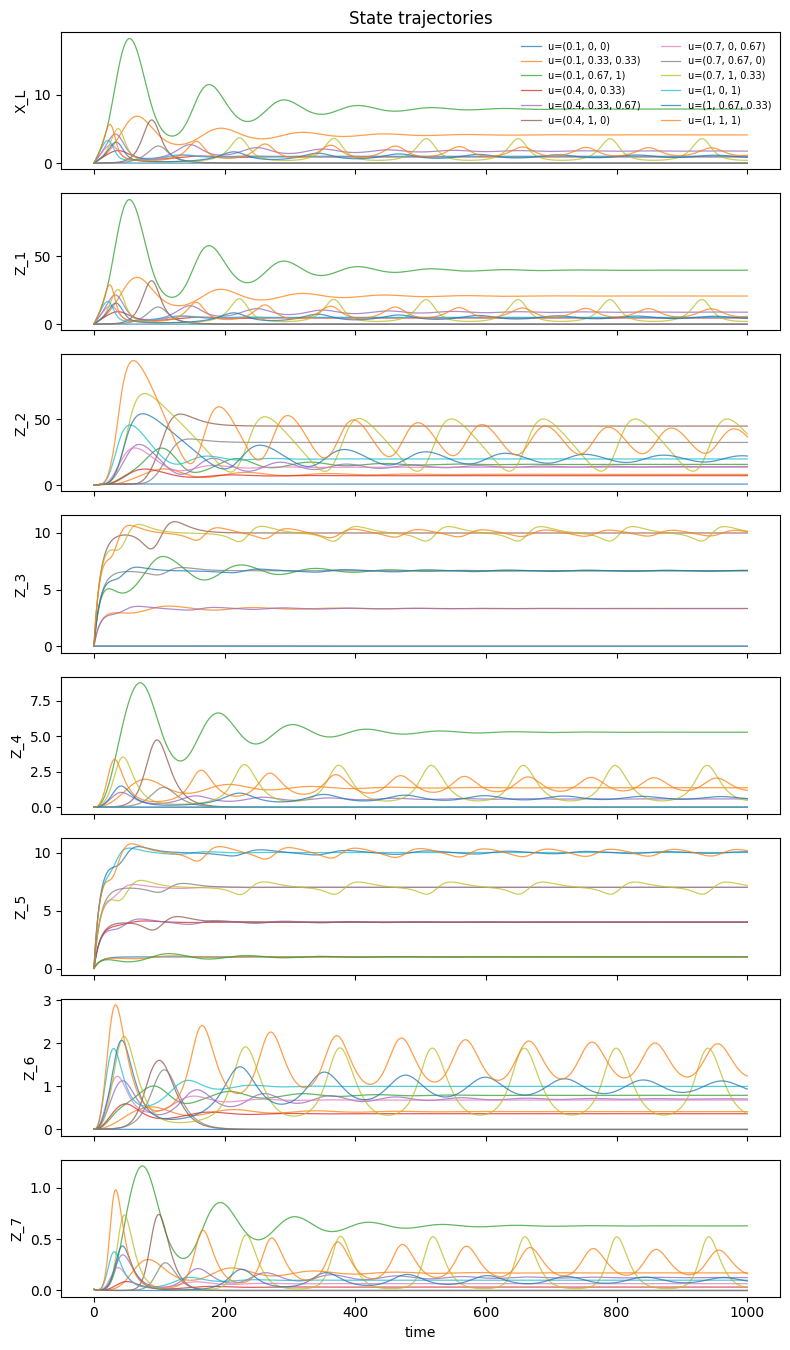

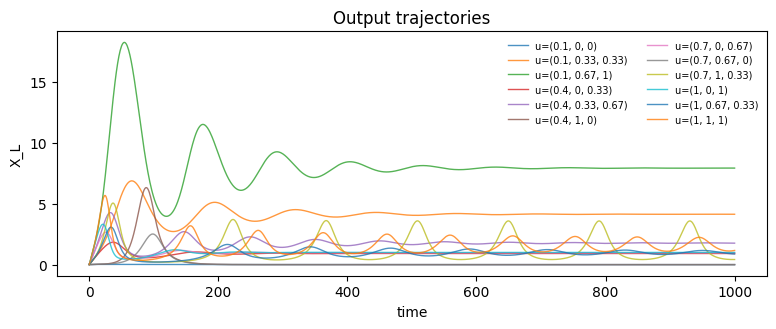

In [8]:
def _selected_trace_indices(n_traces, max_traces=12):
    if n_traces <= max_traces:
        return np.arange(n_traces, dtype=int)
    return np.unique(np.linspace(0, n_traces - 1, max_traces, dtype=int))


def plot_state_trajectories(time, states, u_list, *, species_labels=None, max_traces=12):
    trace_indices = _selected_trace_indices(len(states), max_traces=max_traces)
    n_species = np.asarray(states[0]).shape[0]

    if species_labels is None:
        species_labels = [f"X_{i + 1}" for i in range(n_species)]

    fig, axes = plt.subplots(n_species, 1, figsize=(8.0, 1.7 * n_species), sharex=True)
    axes = np.atleast_1d(axes)

    for idx in trace_indices:
        u = np.asarray(u_list[idx]).reshape(-1)
        label = f"u=({u[0]:.2g}, {u[1]:.2g}, {u[2]:.2g})"
        x = np.asarray(states[idx])
        for s, ax in enumerate(axes):
            ax.plot(time, x[s, :], linewidth=0.9, alpha=0.75, label=label if s == 0 else None)
            ax.set_ylabel(species_labels[s])

    axes[0].set_title("State trajectories")
    axes[0].legend(frameon=False, fontsize=7, ncol=2, loc="upper right")
    axes[-1].set_xlabel("time")
    fig.tight_layout()
    return fig, axes


def plot_output_trajectories(time, outputs, u_list, *, output_label="output", max_traces=12):
    trace_indices = _selected_trace_indices(len(outputs), max_traces=max_traces)

    fig, ax = plt.subplots(figsize=(8.0, 3.4))
    for idx in trace_indices:
        u = np.asarray(u_list[idx]).reshape(-1)
        label = f"u=({u[0]:.2g}, {u[1]:.2g}, {u[2]:.2g})"
        y = np.asarray(outputs[idx])
        ax.plot(time, y[0, :], linewidth=1.0, alpha=0.8, label=label)

    ax.set_title("Output trajectories")
    ax.set_xlabel("time")
    ax.set_ylabel(output_label)
    ax.legend(frameon=False, fontsize=7, ncol=2, loc="best")
    fig.tight_layout()
    return fig, ax


plot_state_trajectories(t_grid, x_grid, grid_inputs, species_labels=iocrn.species_labels, max_traces=12)
plot_output_trajectories(t_grid, y_grid, grid_inputs, output_label=iocrn.output_labels[0], max_traces=12)
plt.show()


## Parity Plot and Error Distributions


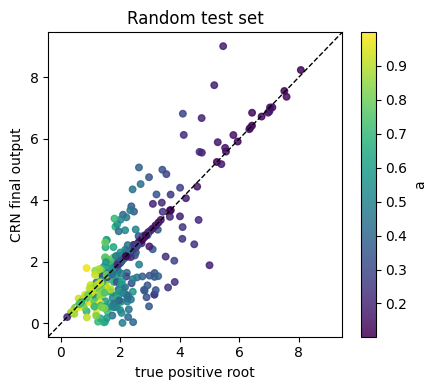

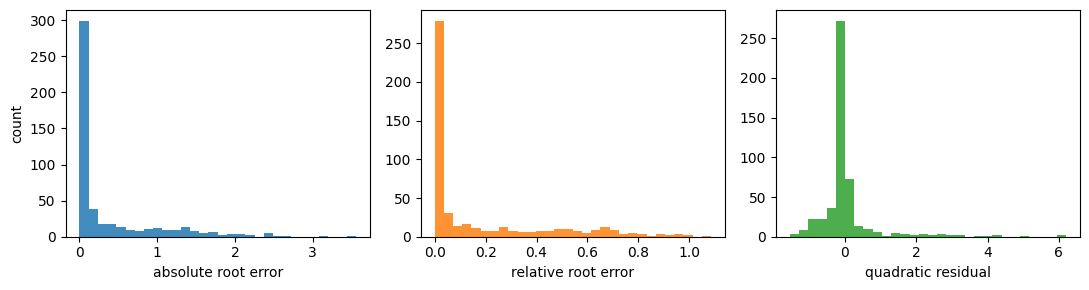

In [9]:
def plot_parity(df, color_by="abs_error", title="Predicted vs true root"):
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    sc = ax.scatter(df["x_true"], df["x_pred"], c=df[color_by], s=22, cmap="viridis", alpha=0.85)
    lo = min(df["x_true"].min(), df["x_pred"].min())
    hi = max(df["x_true"].max(), df["x_pred"].max())
    pad = 0.05 * max(hi - lo, 1e-12)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", linewidth=1.0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("true positive root")
    ax.set_ylabel("CRN final output")
    ax.set_title(title)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(color_by)
    fig.tight_layout()
    return fig, ax


def plot_error_histograms(df):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.0))
    axes[0].hist(df["abs_error"], bins=30, color="C0", alpha=0.85)
    axes[0].set_xlabel("absolute root error")
    axes[0].set_ylabel("count")
    axes[1].hist(df["rel_error"], bins=30, color="C1", alpha=0.85)
    axes[1].set_xlabel("relative root error")
    axes[2].hist(df["residual"], bins=30, color="C2", alpha=0.85)
    axes[2].set_xlabel("quadratic residual")
    fig.tight_layout()
    return fig, axes


fig_parity, ax_parity = plot_parity(df_random, color_by="a", title="Random test set")
fig_hist, axes_hist = plot_error_histograms(df_random)
fig_parity.savefig(
    "Parity_" + figure_name_append + ".pdf",
    bbox_inches="tight",
)
fig_hist.savefig(
    "Hist_" + figure_name_append + ".pdf",
    bbox_inches="tight",
)
plt.show()


## Error Heatmaps Over b and c at Fixed a

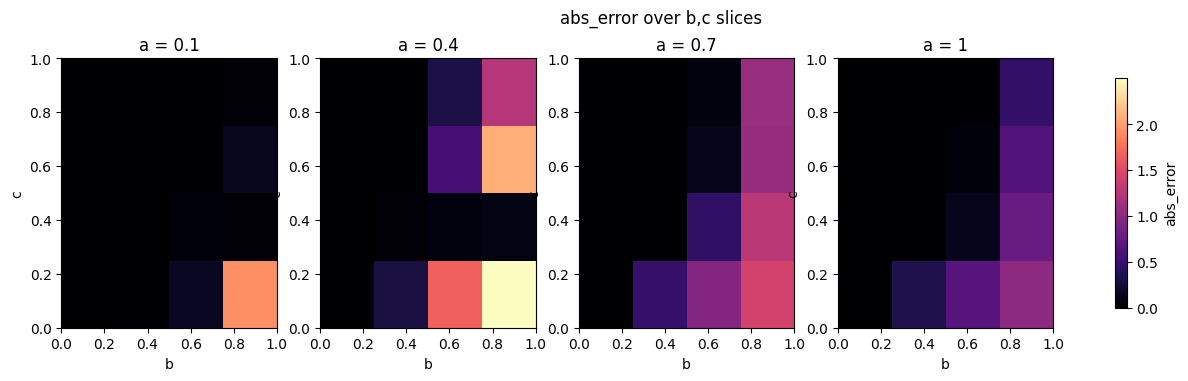

In [10]:
def plot_error_heatmaps(df, a_values_to_plot=None, value="abs_error"):
    if a_values_to_plot is None:
        a_values_to_plot = sorted(df["a"].unique())
    a_values_to_plot = list(a_values_to_plot)

    fig, axes = plt.subplots(1, len(a_values_to_plot), figsize=(4.0 * len(a_values_to_plot), 3.5), squeeze=False)
    vmax = df[value].max()

    for ax, a0 in zip(axes[0], a_values_to_plot):
        sub = df[np.isclose(df["a"], a0)].copy()
        table = sub.pivot(index="c", columns="b", values=value).sort_index(ascending=True)
        im = ax.imshow(
            table.values,
            origin="lower",
            aspect="auto",
            extent=[table.columns.min(), table.columns.max(), table.index.min(), table.index.max()],
            vmin=0.0,
            vmax=vmax,
            cmap="magma",
        )
        ax.set_title(f"a = {a0:g}")
        ax.set_xlabel("b")
        ax.set_ylabel("c")

    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(value)
    fig.suptitle(f"{value} over b,c slices", y=1.02)
    return fig, axes


fig_heatmap, axes_heatmap = plot_error_heatmaps(df_grid, a_values_to_plot=a_values, value="abs_error")
fig_heatmap.savefig(
    "Heatmap_" + figure_name_append + ".pdf",
    bbox_inches="tight",
)
plt.show()

In [11]:
# Animate the feedback response to a gamma disturbance on the parity plot.
# This cell uses the `random_inputs`, `iocrn`, and `quadratic_root` objects defined above.
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# Disturbance settings: simulate to t=500, multiply gamma, then continue to t=1000.
disturbance_time = 500.0
final_time = 1000.0
gamma_mult = 0.5
n_t_pre = 501
n_t_post = 501
ic_value = 0.01
animation_stride = 10
animation_interval_ms = 50


def _find_xl_degradation_reaction(crn, output_label="X_L"):
    matches = [
        reaction
        for reaction in crn.reactions
        if reaction.reactant_labels == [output_label]
        and reaction.product_labels == []
        and not reaction.input_labels
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one {output_label} -> emptyset reaction, found {len(matches)}."
        )
    return matches[0]


def simulate_gamma_disturbance(
    crn,
    inputs,
    *,
    gamma_mult=2.0,
    disturbance_time=500.0,
    final_time=1000.0,
    n_t_pre=501,
    n_t_post=501,
    ic_value=0.01,
):
    sim_crn = crn.clone()
    gamma_reaction = _find_xl_degradation_reaction(sim_crn, output_label=crn.output_labels[0])
    gamma_base = float(gamma_reaction.params[0])

    x0 = np.full(sim_crn.num_species, ic_value, dtype=np.float32)
    t_pre = np.linspace(0.0, disturbance_time, n_t_pre, dtype=np.float32)
    t_pre, states_pre, outputs_pre, _ = sim_crn.transient_response(
        inputs,
        [x0],
        t_pre,
        force=True,
    )

    gamma_reaction.set_parameters([gamma_base * gamma_mult])
    sim_crn.reset()

    restart_states = [state[:, -1].astype(np.float32) for state in states_pre]
    t_post_local = np.linspace(0.0, final_time - disturbance_time, n_t_post, dtype=np.float32)
    t_post_local, states_post, outputs_post, _ = sim_crn.transient_response(
        inputs,
        restart_states,
        t_post_local,
        force=True,
        mode="zip",
    )

    time = np.concatenate([t_pre, disturbance_time + t_post_local[1:]])
    states = [
        np.concatenate([state_pre, state_post[:, 1:]], axis=1)
        for state_pre, state_post in zip(states_pre, states_post)
    ]
    outputs = [
        np.concatenate([output_pre, output_post[:, 1:]], axis=1)
        for output_pre, output_post in zip(outputs_pre, outputs_post)
    ]

    return time, states, outputs, gamma_base, gamma_base * gamma_mult


time_disturbed, states_disturbed, outputs_disturbed, gamma_before, gamma_after = simulate_gamma_disturbance(
    iocrn,
    random_inputs,
    gamma_mult=gamma_mult,
    disturbance_time=disturbance_time,
    final_time=final_time,
    n_t_pre=n_t_pre,
    n_t_post=n_t_post,
    ic_value=ic_value,
)

true_roots = np.array([quadratic_root(*map(float, inputs)) for inputs in random_inputs])
output_over_time = np.vstack([np.asarray(output)[0, :] for output in outputs_disturbed])
input_color = np.asarray(random_inputs)[:, 0]

valid = np.isfinite(true_roots) & np.all(np.isfinite(output_over_time), axis=1)
true_roots = true_roots[valid]
output_over_time = output_over_time[valid]
input_color = input_color[valid]

frame_indices = np.arange(0, len(time_disturbed), animation_stride)
if frame_indices[-1] != len(time_disturbed) - 1:
    frame_indices = np.append(frame_indices, len(time_disturbed) - 1)

predisturbance_mask = time_disturbed <= disturbance_time
predisturbance_outputs = output_over_time[:, predisturbance_mask]
plot_min = 0.0
plot_max = max(
    float(np.nanmax(true_roots)),
    float(np.nanmax(predisturbance_outputs)),
)
pad = 0.05 * (plot_max - plot_min if plot_max > plot_min else 1.0)

fig, ax = plt.subplots(figsize=(6.5, 6.0))
ax.plot([plot_min - pad, plot_max + pad], [plot_min - pad, plot_max + pad], "k--", lw=1.0, alpha=0.6)
points = ax.scatter(
    true_roots,
    output_over_time[:, 0],
    c=input_color,
    cmap="viridis",
    s=18,
    alpha=0.75,
    edgecolors="none",
)
ax.axhline(ic_value, color="0.75", lw=0.8, ls=":")
ax.set_xlim(plot_min - pad, plot_max + pad)
ax.set_ylim(plot_min - pad, plot_max + pad)
ax.set_xlabel("true positive root")
ax.set_ylabel(f"{iocrn.output_labels[0]}(t)")
ax.grid(True, alpha=0.25)
colorbar = fig.colorbar(points, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("u_1")
time_text = ax.text(0.03, 0.97, "", transform=ax.transAxes, va="top")


def update(frame_number):
    idx = frame_indices[frame_number]
    points.set_offsets(np.column_stack([true_roots, output_over_time[:, idx]]))
    time_text.set_text(
        f"t = {time_disturbed[idx]:.1f}\n"
        f"gamma: {gamma_before:.3g} -> {gamma_after:.3g} at t = {disturbance_time:.0f}"
    )
    return points, time_text


animation = FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    interval=animation_interval_ms,
    blit=False,
)

animation.save(
    "gamma_disturbance_parity_unstable.gif",
    writer="pillow",
    fps=20,
)

plt.close(fig)
display(HTML(animation.to_jshtml()))


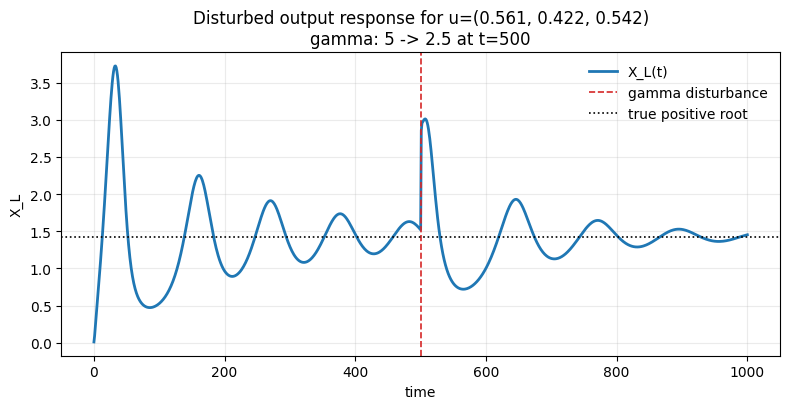

In [12]:
# Plot one disturbed output trajectory over time.
# Change this index to inspect another sampled input from `random_inputs`.
input_index = 0

selected_input = np.asarray(random_inputs[input_index], dtype=float)
selected_root = quadratic_root(*selected_input)

# Reuse the disturbed simulations from the animation cell when available.
# If they are not available, simulate just this one input with the same disturbance settings.
if "time_disturbed" in globals() and "outputs_disturbed" in globals():
    time_single = time_disturbed
    output_single = np.asarray(outputs_disturbed[input_index])[0]
    gamma_before_single = gamma_before
    gamma_after_single = gamma_after
else:
    time_single, _, outputs_single, gamma_before_single, gamma_after_single = simulate_gamma_disturbance(
        iocrn,
        [selected_input.astype(np.float32)],
        gamma_mult=gamma_mult,
        disturbance_time=disturbance_time,
        final_time=final_time,
        n_t_pre=n_t_pre,
        n_t_post=n_t_post,
        ic_value=ic_value,
    )
    output_single = np.asarray(outputs_single[0])[0]

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.plot(time_single, output_single, lw=2.0, label=f"{iocrn.output_labels[0]}(t)")
ax.axvline(disturbance_time, color="tab:red", ls="--", lw=1.2, label="gamma disturbance")
ax.axhline(selected_root, color="k", ls=":", lw=1.2, label="true positive root")
ax.set_xlabel("time")
ax.set_ylabel(iocrn.output_labels[0])
ax.set_title(
    f"Disturbed output response for "
    f"u=({selected_input[0]:.3g}, {selected_input[1]:.3g}, {selected_input[2]:.3g})\n"
    f"gamma: {gamma_before_single:.3g} -> {gamma_after_single:.3g} at t={disturbance_time:.0f}"
)
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [13]:
idx = np.searchsorted(time_disturbed, disturbance_time)
print(time_disturbed[idx-2:idx+5])
print(output_single[idx-2:idx+5])

[498. 499. 500. 501. 502. 503. 504.]
[1.54003068 1.52971409 1.51913091 2.85565156 2.95334852 2.96970777
 2.98433771]
